# Proof of concept: Matrix Wavelet Transforms in 1D with CVXPY

February 16, 2024

Convert the wavelet deconstruction and reconstruction process into matrix kernels and multiplications. This allows us to perform these processes with the cvxpy operations and optimize the reconstruction.

This will help us translate this process into the second dimension, such that we can optimize and constrain over the reconstruction of the chromatin images. 


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
import numpy as np
import pywt

In [4]:
import pywt

wavelet = pywt.Wavelet('bior4.4')
# Obtain filters
dec_lo, dec_hi = wavelet.dec_lo, wavelet.dec_hi
rec_lo, rec_hi = wavelet.rec_lo, wavelet.rec_hi

In [5]:
from src.linalg_wavelets import create_downsample_convolution_matrix, \
    create_upsample_convolution_matrix

# Sample signal
np.random.seed(132)
signal = np.sin(np.linspace(0, 8 * np.pi, 32)) + 0.5 * np.random.randn(32)

n = len(signal)

# Wavelet selection
wavelet = pywt.Wavelet('db1')

# Create matrices that will decompose and downsample
down_lo_mat = create_downsample_convolution_matrix(n, dec_lo)
down_hi_mat = create_downsample_convolution_matrix(n, dec_hi)

# Create matrices that will upsample and reconstruct
up_hi_rec_mat = create_upsample_convolution_matrix(n, rec_hi)
up_lo_rec_mat = create_upsample_convolution_matrix(n, rec_lo)

# Decomposition
approximation = np.matmul(signal, down_lo_mat)
detail = np.matmul(signal, down_hi_mat)

# Reconstruction
reconstructed_approximation = np.matmul(approximation, up_lo_rec_mat)
reconstructed_detail = np.matmul(detail, up_hi_rec_mat)

# Combine
reconstructed_signal = reconstructed_approximation + reconstructed_detail


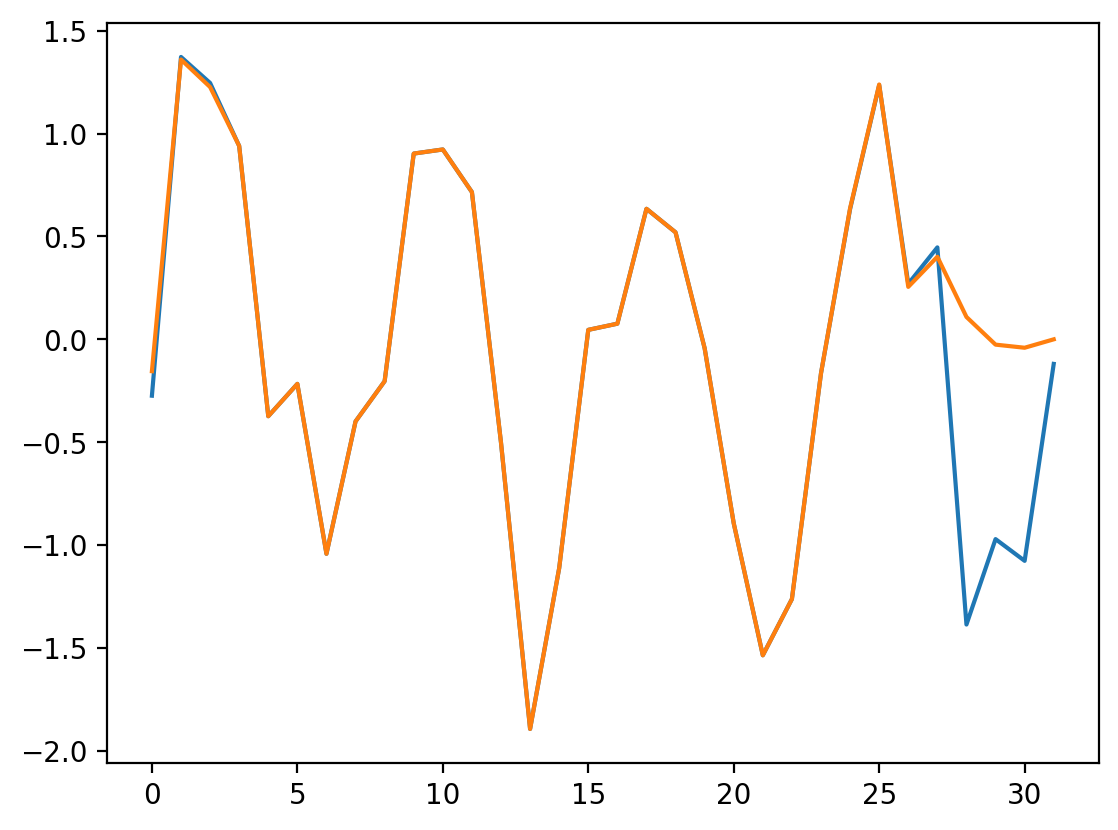

In [6]:
plt.plot(signal)
plt.plot(reconstructed_signal)

Before moving on the 2D, it is worth seeing if it is possible to perform these operations within cvxpy

Input:
- Signal
- Hi deconstruction filter
- Low deconstruction filter
- Hi reconstruction filter
- Low reconstruction filter

### Process:
Take the signal as input, perform deconstruction, threshold, and reconstruction. Can we optimize to minimize the difference between the signal and the reconstruction. The idea may be trivial, but the point is to check if we can perform these deconstruction and reconstruction operations within an optimization objective.

### Notes:
- Variable setting is done with constraints
    - This will be important when we create variables for the upsampling and convolution results.
    - For downsampling, the cvxpy.convolve works when the input signal is constant. However, for 2D images we will eventually need this convolve function to accept a variable input.
    - For upsampling, we need an upsampled array that contains the input signal with zeros.
- We will need to generalize the convolve function


In [7]:
import cvxpy

n = len(signal)
n_2 = n//2

approx_signal = cvxpy.Variable(n)

# Decomposition
approximation = (approx_signal@down_lo_mat)
detail = (approx_signal@down_hi_mat)

# Reconstruction
reconstructed_approximation = (approximation@up_lo_rec_mat)
reconstructed_detail = (detail@up_hi_rec_mat)

reconstruction = reconstructed_approximation + reconstructed_detail

objective = cvxpy.Minimize(
    cvxpy.sum_squares(signal - approx_signal) +
    cvxpy.sum_squares(signal - reconstruction)
)

constraints = []#[reconstruction >= 0]

# Perform the convex optimization
prob = cvxpy.Problem(objective, constraints)

# The epsilon value affects the precision of the solver
result = prob.solve(solver=cvxpy.MOSEK, verbose=True)


                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Feb 16 01:13:38 PM: Your problem has 32 variables, 0 constraints, and 0 parameters.
(CVXPY) Feb 16 01:13:38 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 16 01:13:38 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 16 01:13:38 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 16 01:13:38 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 16 01:13:38 PM: Compiling problem (target solver=MOSEK).
(CV

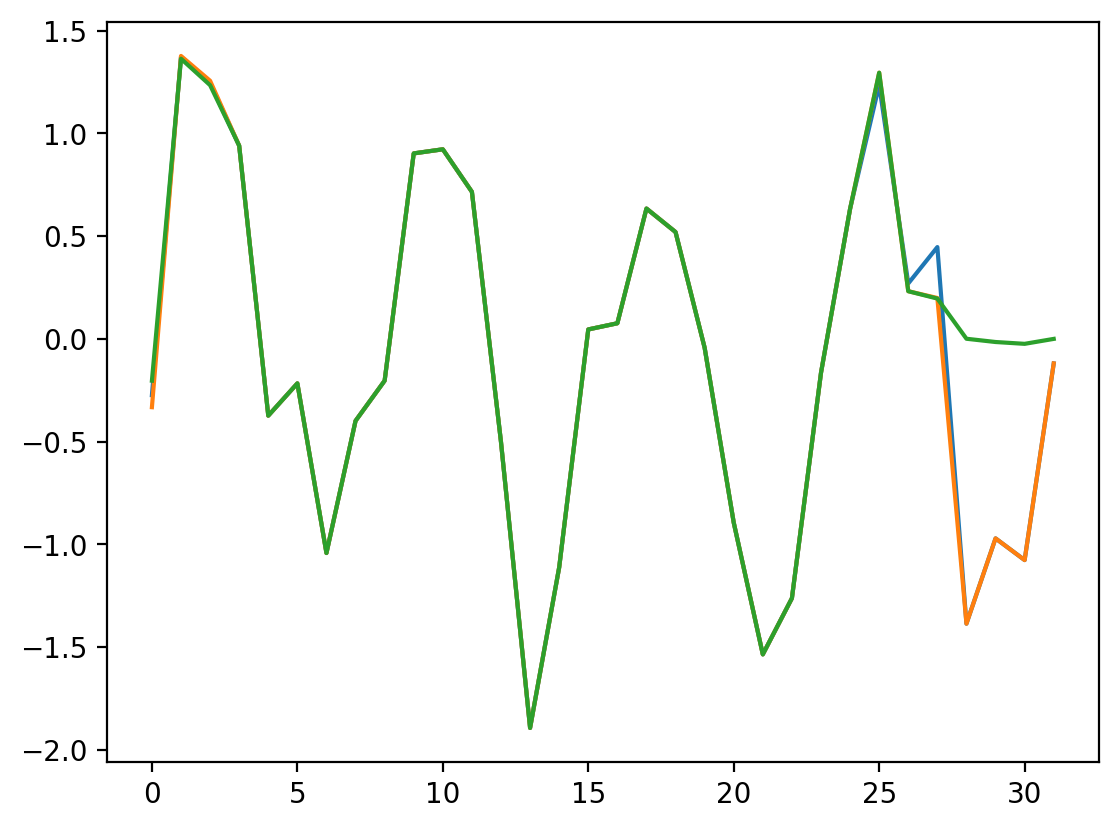

In [8]:
plt.plot(signal)
plt.plot(approx_signal.value)
plt.plot(reconstruction.value)